# 03 — Seasonal Analysis
**Project:** Climate-Driven Solar Energy Analytics  
**Goal:** Understand how solar radiation and related climate variables change across months and Indian seasons.

---
### Why seasonal analysis matters for ML
Solar radiation has a strong **periodic pattern** — it peaks in summer and dips in monsoon/winter.
If we feed raw date numbers into a model, it may not capture this cycle well.
By explicitly engineering **MONTH** and **SEASON** features, we give the model the cyclical context it needs.

This notebook also prepares us for city comparison — we'll check whether Bengaluru's pattern
holds for other cities or if patterns diverge.

In [1]:
# ── Imports & config ──────────────────────────────────────────────────────
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import numpy as np

plt.rcParams.update({
    "figure.dpi": 120,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "axes.titlesize": 13,
    "axes.labelsize": 11,
})

TARGET = "ALLSKY_SFC_SW_DWN"
CITY   = "Bengaluru"
MONTH_ORDER = ["January","February","March","April","May","June",
               "July","August","September","October","November","December"]

# Indian meteorological seasons
# Reference: India Meteorological Department classification
SEASON_MAP = {
    1:  "Winter",    2: "Winter",
    3:  "Pre-Monsoon", 4: "Pre-Monsoon", 5: "Pre-Monsoon",
    6:  "Monsoon",   7: "Monsoon",   8: "Monsoon",   9: "Monsoon",
    10: "Post-Monsoon", 11: "Post-Monsoon",
    12: "Winter"
}
SEASON_ORDER = ["Winter", "Pre-Monsoon", "Monsoon", "Post-Monsoon"]
SEASON_COLORS = {
    "Winter"       : "#4e79a7",
    "Pre-Monsoon"  : "#f28e2b",
    "Monsoon"      : "#59a14f",
    "Post-Monsoon" : "#e15759",
}

In [2]:
# ── Load data & add time features ──────────────────────────────────────────
df = pd.read_csv(f"../data/raw/{CITY}.csv", skiprows=17)

df["DATE"] = pd.to_datetime({
    "year":  df["YEAR"],
    "month": df["MO"],
    "day":   df["DY"]
})
df = df.set_index("DATE")

# New time-based columns
df["MONTH_NAME"] = df.index.month_name()
df["MONTH_NUM"]  = df.index.month
df["SEASON"]     = df["MONTH_NUM"].map(SEASON_MAP)

print(f"City: {CITY}  |  Rows: {len(df)}  |  Period: {df.index.min().date()} – {df.index.max().date()}")
print("\nSeason distribution:")
print(df["SEASON"].value_counts())

City: Bengaluru  |  Rows: 2192  |  Period: 2019-01-01 – 2024-12-31

Season distribution:
SEASON
Monsoon         732
Pre-Monsoon     552
Winter          542
Post-Monsoon    366
Name: count, dtype: int64


---
## 1 · Monthly Average Solar Radiation
We group daily records by **calendar month** and compute the mean, min, and max.
The error bars (min/max) show how much day-to-day variability exists within each month.

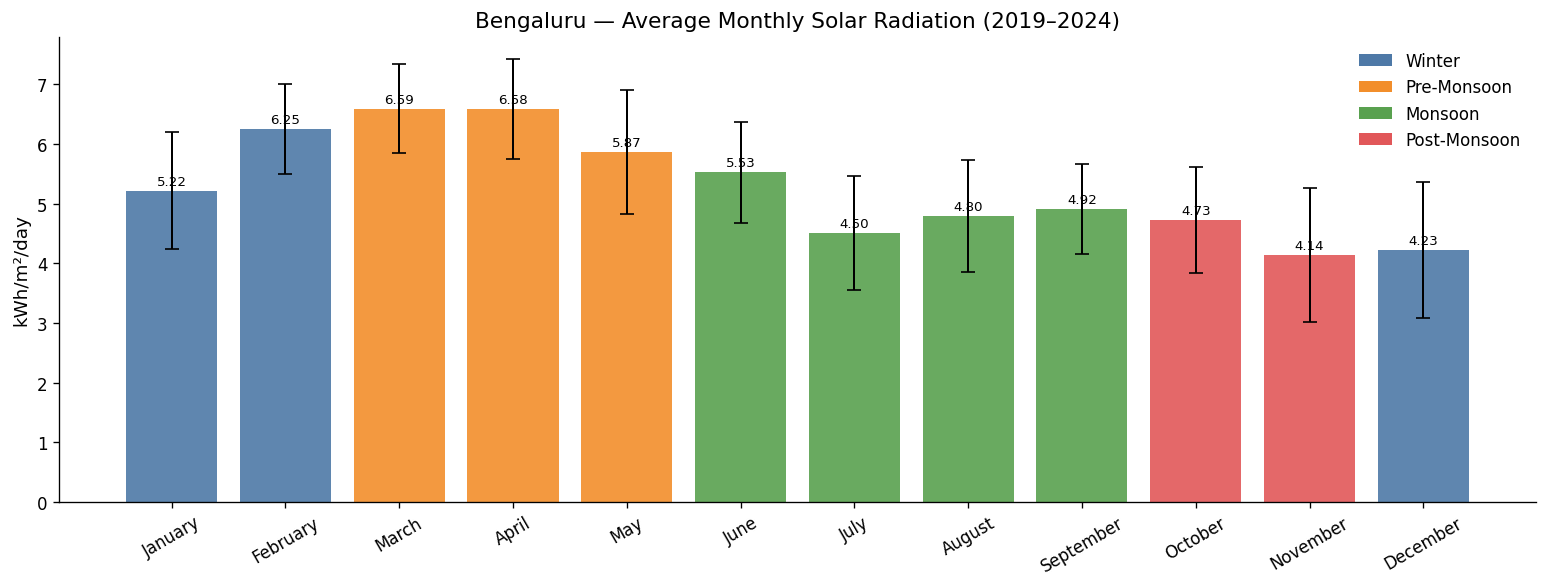


Top 3 months  : {'March': 6.59184623655914, 'April': 6.584243333333333, 'February': 6.248482352941176}
Bottom 3 months: {'November': 4.13861, 'December': 4.227830107526882, 'July': 4.504833333333333}


In [3]:
monthly = (
    df.groupby("MONTH_NAME")[TARGET]
    .agg(["mean", "min", "max", "std"])
    .reindex(MONTH_ORDER)
    .rename(columns={"mean": "Mean", "min": "Min", "max": "Max", "std": "Std"})
)

# Colour each bar by its season
month_to_season = {m: SEASON_MAP[i+1] for i, m in enumerate(MONTH_ORDER)}
bar_colors = [SEASON_COLORS[month_to_season[m]] for m in monthly.index]

fig, ax = plt.subplots(figsize=(13, 5))
bars = ax.bar(
    monthly.index, monthly["Mean"],
    color=bar_colors, edgecolor="none", alpha=0.9,
    yerr=monthly["Std"], capsize=4, error_kw={"color": "#333", "linewidth": 1.2}
)

# Value labels
for bar, val in zip(bars, monthly["Mean"]):
    ax.text(bar.get_x() + bar.get_width()/2, val + 0.05,
            f"{val:.2f}", ha="center", va="bottom", fontsize=8)

# Legend for seasons
from matplotlib.patches import Patch
legend_elements = [Patch(facecolor=c, label=s) for s, c in SEASON_COLORS.items()]
ax.legend(handles=legend_elements, frameon=False, loc="upper right")

ax.set_title(f"{CITY} — Average Monthly Solar Radiation (2019–2024)")
ax.set_ylabel("kWh/m²/day")
ax.tick_params(axis="x", rotation=30)
plt.tight_layout()
plt.show()

print("\nTop 3 months  :", monthly["Mean"].nlargest(3).to_dict())
print("Bottom 3 months:", monthly["Mean"].nsmallest(3).to_dict())

---
## 2 · Season-Level Boxplots
A boxplot shows the **full distribution** of daily solar radiation within each season.
The box spans Q1–Q3 (middle 50 % of data), the line is the median, and whiskers extend to 1.5×IQR.

Why boxplots over just means? The mean hides whether the season is *consistently* good
or just *occasionally* great. For solar farm planning, consistency matters.

/var/folders/nr/4wnmz14s35q9hpmt8qw960d40000gn/T/ipykernel_95168/1930410420.py:4: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(


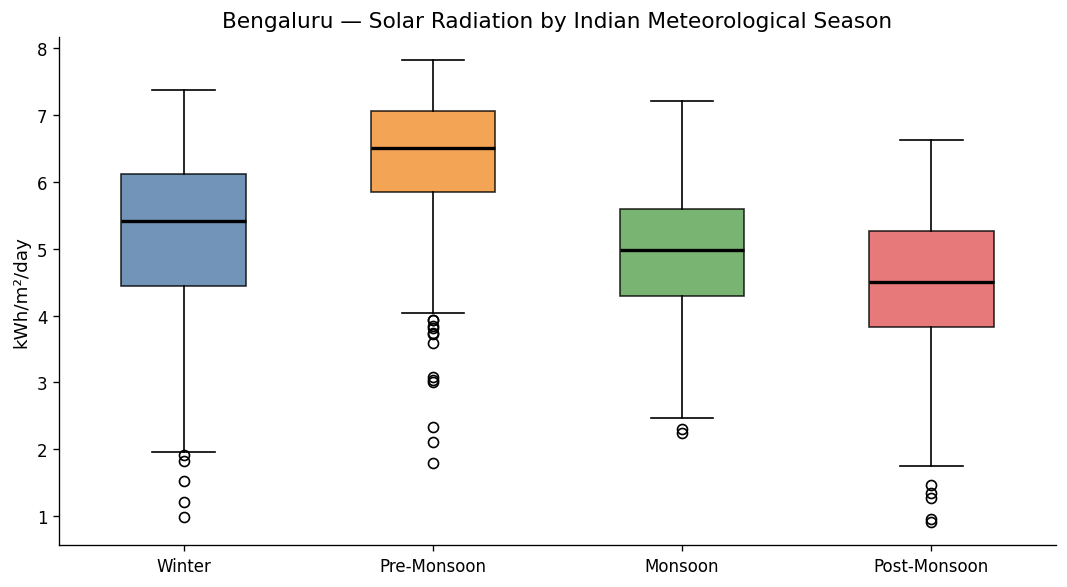


Seasonal statistics:
              count   mean    std    min    25%    50%    75%    max
SEASON                                                              
Winter        542.0  5.202  1.274  0.992  4.440  5.423  6.113  7.369
Pre-Monsoon   552.0  6.347  0.947  1.794  5.843  6.512  7.064  7.823
Monsoon       732.0  4.932  0.953  2.237  4.290  4.986  5.595  7.218
Post-Monsoon  366.0  4.437  1.055  0.908  3.835  4.508  5.273  6.629


In [4]:
season_data = [df[df["SEASON"] == s][TARGET].values for s in SEASON_ORDER]

fig, ax = plt.subplots(figsize=(9, 5))
bp = ax.boxplot(
    season_data, labels=SEASON_ORDER,
    patch_artist=True, widths=0.5,
    medianprops={"color": "black", "linewidth": 2}
)
for patch, season in zip(bp["boxes"], SEASON_ORDER):
    patch.set_facecolor(SEASON_COLORS[season])
    patch.set_alpha(0.8)

ax.set_title(f"{CITY} — Solar Radiation by Indian Meteorological Season")
ax.set_ylabel("kWh/m²/day")
plt.tight_layout()
plt.show()

print("\nSeasonal statistics:")
print(df.groupby("SEASON")[TARGET].describe().round(3).reindex(SEASON_ORDER))

---
## 3 · All Climate Variables — Monthly Profiles
Solar radiation doesn't fluctuate in isolation. Here we plot how every input feature
also varies month-by-month. This gives us a visual *signature* of Bengaluru's climate year.

Notice how humidity and cloud cover mirror solar radiation in an inverse pattern — these are
the dominant controls on how much sunlight reaches the surface.

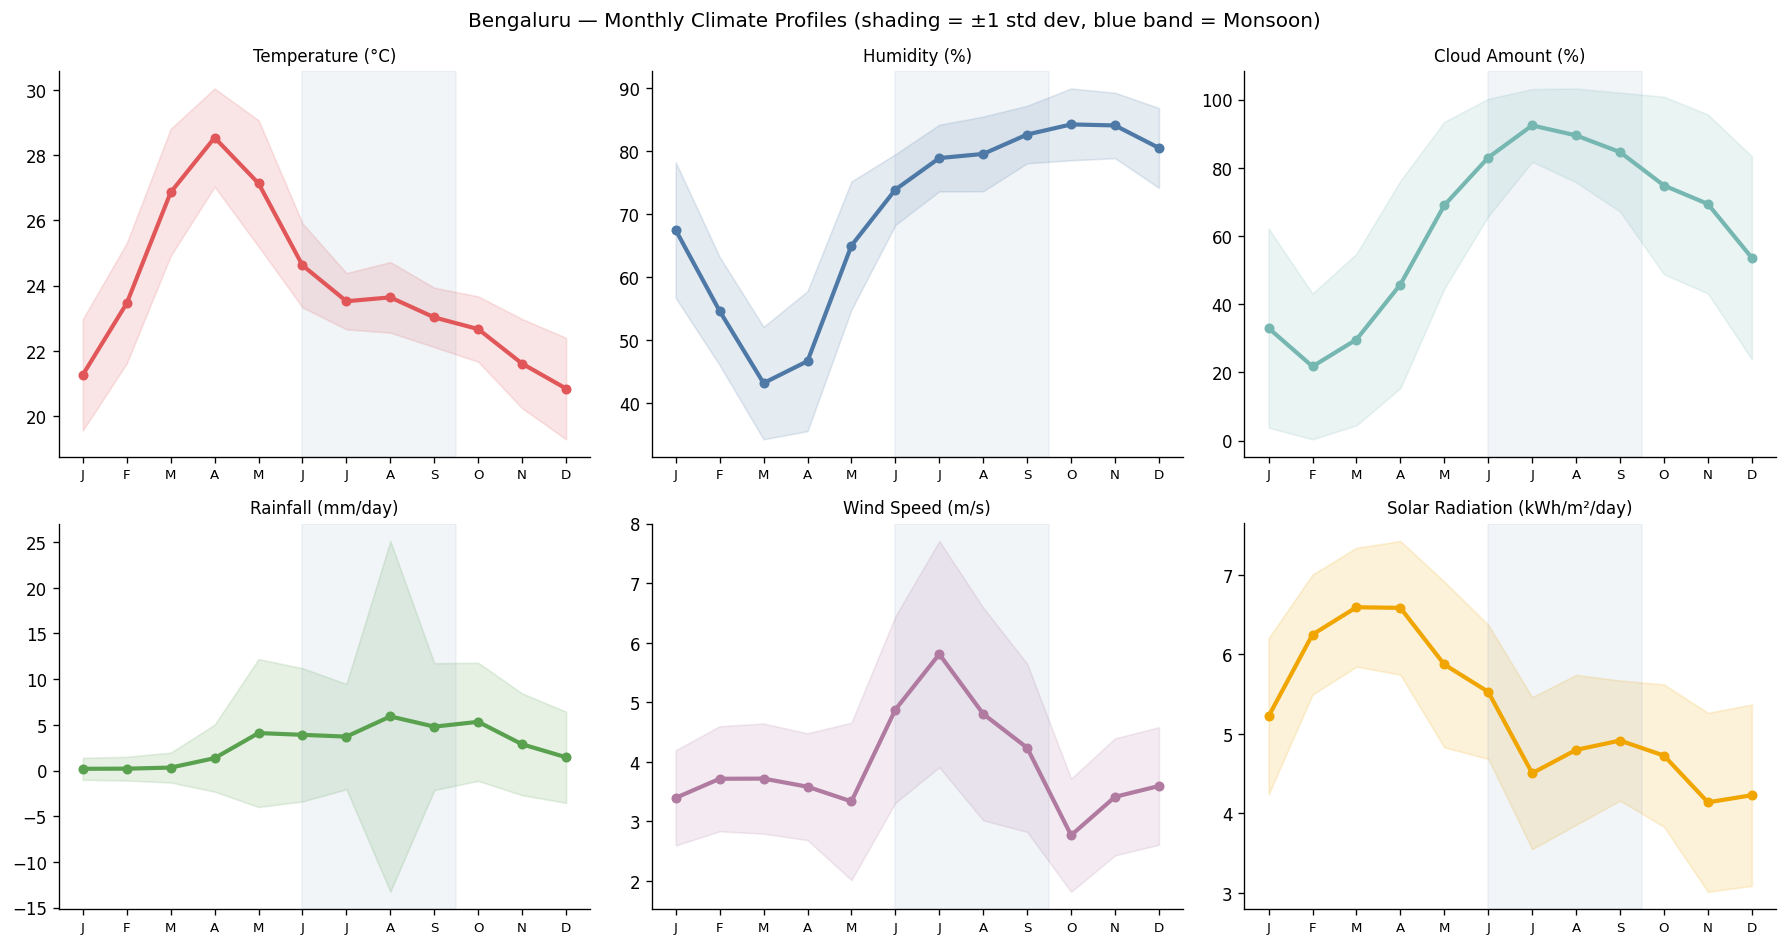

In [5]:
CLIMATE_VARS = [
    ("T2M",         "Temperature (°C)",      "#e15759"),
    ("RH2M",        "Humidity (%)",           "#4e79a7"),
    ("CLOUD_AMT",   "Cloud Amount (%)",       "#76b7b2"),
    ("PRECTOTCORR", "Rainfall (mm/day)",      "#59a14f"),
    ("WS10M",       "Wind Speed (m/s)",       "#b07aa1"),
    (TARGET,        "Solar Radiation (kWh/m²/day)", "#f0a500"),
]

fig, axes = plt.subplots(2, 3, figsize=(15, 8))

for ax, (col, label, color) in zip(axes.flat, CLIMATE_VARS):
    mo_avg = df.groupby("MONTH_NUM")[col].mean().reindex(range(1, 13))
    mo_std = df.groupby("MONTH_NUM")[col].std().reindex(range(1, 13))

    ax.plot(range(1, 13), mo_avg, color=color, linewidth=2.5, marker="o", markersize=5)
    ax.fill_between(range(1, 13),
                    mo_avg - mo_std, mo_avg + mo_std,
                    color=color, alpha=0.15)
    ax.set_title(label, fontsize=10)
    ax.set_xticks(range(1, 13))
    ax.set_xticklabels(["J","F","M","A","M","J","J","A","S","O","N","D"], fontsize=8)
    ax.axvspan(6, 9.5, alpha=0.07, color="#4e79a7")  # highlight monsoon

fig.suptitle(f"{CITY} — Monthly Climate Profiles (shading = ±1 std dev, blue band = Monsoon)",
             fontsize=12)
plt.tight_layout()
plt.show()

---
## 4 · Year × Month Heatmap
A heatmap with Year on Y-axis and Month on X-axis shows:
1. Whether the seasonal pattern repeats consistently year-to-year (it should).
2. Any anomalous year — e.g. an unusually wet or dry spell — which would appear as
   a row that diverges from its neighbours.

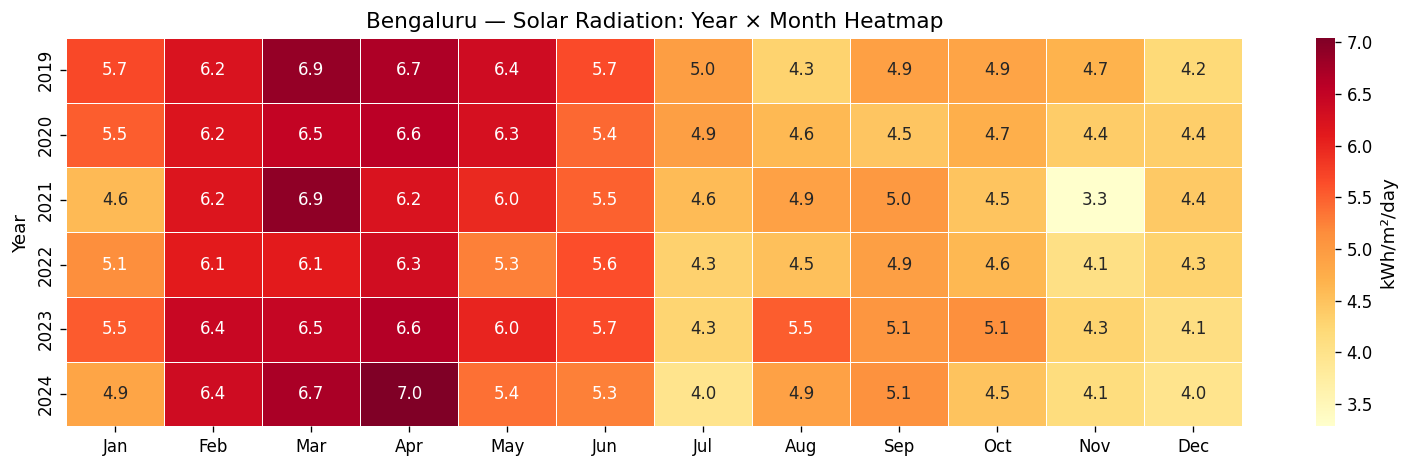


Interpretation:
  • Consistent colour pattern across rows = stable seasonal cycle year after year.
  • Any row significantly lighter/darker = anomalous weather that year.
  • This stability validates that MONTH is a reliable engineered feature for ML.



In [6]:
import seaborn as sns

pivot = (
    df.groupby(["YEAR", "MONTH_NUM"])[TARGET]
    .mean()
    .unstack(level=1)
    .rename(columns={i: m[:3] for i, m in enumerate(MONTH_ORDER, 1)})
)

fig, ax = plt.subplots(figsize=(13, 4))
sns.heatmap(
    pivot, annot=True, fmt=".1f", cmap="YlOrRd",
    linewidths=0.5, ax=ax,
    cbar_kws={"label": "kWh/m²/day"}
)
ax.set_title(f"{CITY} — Solar Radiation: Year × Month Heatmap")
ax.set_xlabel("")
ax.set_ylabel("Year")
plt.tight_layout()
plt.show()

print("""
Interpretation:
  • Consistent colour pattern across rows = stable seasonal cycle year after year.
  • Any row significantly lighter/darker = anomalous weather that year.
  • This stability validates that MONTH is a reliable engineered feature for ML.
""")

---
## ✅ Seasonal Analysis Summary

| Season | Months | Avg Solar Radiation | Reason |
|--------|--------|-------------------|--------|
| Pre-Monsoon | Mar–May | **Highest** | Clear skies, sun near overhead |
| Winter | Jan–Feb, Dec | Moderate | Clear but shorter days |
| Post-Monsoon | Oct–Nov | Moderate | Drying out after monsoon |
| Monsoon | Jun–Sep | **Lowest** | Heavy cloud and rain block sunlight |

**Features to engineer in Phase 5:**
- `MONTH` (integer 1–12) — captures ordinal seasonality  
- `SEASON` (categorical) — coarser but robust grouping  
- `TEMP_RANGE` = T2M_MAX − T2M_MIN — daily thermal amplitude correlates with clear skies  
- `IS_MONSOON` (binary flag) — the biggest single-cut predictor based on this analysis

**Next notebook →** `04_city_comparison.ipynb` — does this seasonal pattern hold across all 15 cities?